In [1]:
import os
import sys
import argparse
import logging

# ── tqdm monkey-patch (required before MIOFlow imports) ────────────────────
import tqdm as _tqdm
import tqdm.notebook
tqdm.notebook.tqdm = _tqdm.tqdm

import numpy as np
import pandas as pd
import torch
import scanpy as sc

# from MIOFlow.models import make_model, Autoencoder
# from MIOFlow.gaga import Autoencoder, train_gaga_two_phase, train_valid_loader_from_pc

In [2]:
from mioflow.gaga import Autoencoder, train_gaga_two_phase, dataloader_from_pc, train_valid_loader_from_pc
from mioflow.mioflow import MIOFlow

In [3]:
os.chdir("/rds/user/wz369/hpc-work/PINN_dynamics")
sys.path.append("scripts")
import fate_eval_pipeline as fate_eval

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances

In [5]:
adata = sc.read_h5ad("data/klein_addpop.h5ad")

In [6]:
train_ad = adata[adata.obs.Well !=2].copy()
test_ad = adata[adata.obs.Well ==2].copy()
train_ad

AnnData object with n_obs × n_vars = 72051 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group', 'timepoint_tx_days', 'selected_clonal_cells', 'palantir_pseudotime', 'palantir_entropy', 'split', 'bifate_mask'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'DM_EigenValues', 'Meta clones_colors', 'Population_colors', 'Time_point_colors', 'comb_colors', 'diffmap_evals', 'group_colors', 'hvg', 'iroot', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'root_cb', 'time_cat_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_diffmap', 'X_pca', 'X_pca_scaled', 'X_umap', 'delta_DM', 'delta_PC', 'guassian_kde_u_DM_EigenVectors', 'palantir_fate_probabilities'
    varm: 'PCs'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connecti

In [7]:
# X_pca = train_ad.obsm['X_pca'][:,:30]
# D_phate = 
import phate
phate_op = phate.PHATE(n_components=2, n_jobs=-2)
X_phate = phate_op.fit_transform(train_ad.obsm['X_pca'][:,:30])

train_ad.obsm['X_phate'] = X_phate

Calculating PHATE...
  Running PHATE on 72051 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...


    Calculated KNN search in 21.35 seconds.
    Calculating affinities...
    Calculated affinities in 4.36 seconds.
  Calculated graph and diffusion operator in 25.79 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 5.19 seconds.
    Calculating KMeans...
    Calculated KMeans in 11.06 seconds.
  Calculated landmark operator in 16.25 seconds.
  Calculating optimal t...
    Automatically selected t = 22
  Calculated optimal t in 2.42 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 2.05 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 3.40 seconds.
Calculated PHATE in 51.48 seconds.


In [8]:
# ── Scale PCA inputs (same normalisation used during GAGA training) ──────────
X_pca_raw  = train_ad.obsm['X_pca'].astype(np.float32)
scaler_pca = StandardScaler().fit(X_pca_raw)
X_pca      = scaler_pca.transform(X_pca_raw)

# ── PHATE-based pairwise distances for geometric regularisation ──────────────
scaler_phate    = StandardScaler().fit(train_ad.obsm['X_phate'])
X_phate_scaled  = scaler_phate.transform(train_ad.obsm['X_phate'])
phate_distances = pairwise_distances(X_phate_scaled, metric='euclidean').astype(np.float32)

# ── Build model + dataloader ─────────────────────────────────────────────────
input_dim  = X_pca.shape[1]   # 50 PCA components
latent_dim = 2                 # match PHATE dimensionality

gaga_model  = Autoencoder(input_dim, latent_dim, hidden_dims=[128, 64])
gaga_loader = dataloader_from_pc(X_pca, phate_distances, batch_size=1024)
print(f'GAGA architecture: {input_dim} → {latent_dim}')

# ── Two-phase training ───────────────────────────────────────────────────────
gaga_history = train_gaga_two_phase(
    gaga_model,
    gaga_loader,
    encoder_epochs=10,       # Phase 1: distance preservation
    decoder_epochs=10,       # Phase 2: reconstruction
    learning_rate=1e-3,
    dist_weight_phase1=1.0,
    recon_weight_phase2=1.0,
)

GAGA architecture: 50 → 2
Phase 1: Training encoder (decoder frozen) for distance preservation
Training GAGA on device: cuda
Encoder frozen: False, Decoder frozen: True
Reconstruction weight: 0.0, Distance weight: 1.0


Epochs: 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:28<00:00, 38.89s/it, train_loss=0.0346, recon=1.0235, dist=0.0346]



Phase 2: Training decoder (encoder frozen) for reconstruction
Training GAGA on device: cuda
Encoder frozen: True, Decoder frozen: False
Reconstruction weight: 1.0, Distance weight: 0.0


Epochs: 100%|████████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:18<00:00, 37.80s/it, train_loss=0.7785, recon=0.7785, dist=0.0329]


In [ ]:
ckpt = {
    'model_state_dict': gaga_model.state_dict(),
    'input_dim': input_dim,
    'latent_dim': latent_dim,
    'hidden_dims': [128, 64],
    'scaler_pca': scaler_pca,        # StandardScaler for PCA inputs
    'scaler_phate': scaler_phate,    # StandardScaler for PHATE (if needed later)
}
torch.save(ckpt, 'logs/MIOFlow/pca_gaga_checkpoint.pt')

In [13]:
gaga_model.input_scaler

,copy,True
,with_mean,True
,with_std,True


# init the MIOFlow

In [ ]:
gaga_model.input_scaler = scaler_pca

In [24]:
mf = MIOFlow(
    adata,
    gaga_model=gaga_model.to('cpu'),
    gaga_input_key='X_pca',    # fitted on X_pca — used for encode() and inverse_transform()
    obs_time_key='Time_point',
    debug_level='info',
    hidden_dim = 128,
    use_cuda = torch.cuda.is_available(),
    momentum_beta = 0.0,
    # Training phases
    # n_local_epochs=10,
    n_epochs=100,
    # n_post_local_epochs=10,
    # Loss
    use_density_loss=True,
    lambda_ot = 1.0,
    lambda_density=0.1,
    lambda_energy=0.01,
    energy_time_steps=20,
    # Data / output
    sample_size=100,
    n_trajectories=100,
    n_bins=100,
    exp_dir='.',
)

2026-03-13 21:44:24,612 - MIOFlow - INFO - MIOFlow initialised | 126861 cells, 5000 genes | device=cuda


In [25]:
mf.fit()
print(mf)

2026-03-13 21:44:27,896 - MIOFlow - INFO - ODEFunc: input_dim=2, hidden_dim=128
2026-03-13 21:44:27,897 - MIOFlow - INFO - Global training: 100 epochs
Training (global): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [27:47<00:00, 16.67s/it]
2026-03-13 22:12:19,957 - MIOFlow - INFO - Trajectories generated: shape=(100, 100, 2)
2026-03-13 22:12:19,957 - MIOFlow - INFO - MIOFlow fitting completed.


MIOFlow(n_obs=126861, gaga=Autoencoder, n_epochs=100, trajectories=(100, 100, 2), status=fitted)


In [31]:
ckpt_mf = {
    # ODE dynamics
    'ode_state_dict': mf.ode_model.state_dict(),
    'ode_class': type(mf.ode_model).__name__,   # 'ODEFunc' or 'SDEFunc'
    'hidden_dim': mf.hidden_dim,
    'input_dim': mf.ode_model.model[0].in_features,
    # Normalization (applied in latent space before ODE)
    'mean_vals': mf.mean_vals,
    'std_vals': mf.std_vals,
    # GAGA autoencoder (already saved separately, but convenient to bundle)
    'gaga_state_dict': mf.gaga_autoencoder.state_dict(),
    'gaga_input_dim': input_dim,
    'gaga_latent_dim': latent_dim,
    'gaga_hidden_dims': [128, 64],
    'scaler_pca': scaler_pca,
    # Losses for reference
    'losses': mf.losses,
}
torch.save(ckpt_mf, 'logs/MIOFlow/mioflow_pca_gaga_checkpoint.pt')

# checking losses

In [37]:
import matplotlib.pyplot as plt

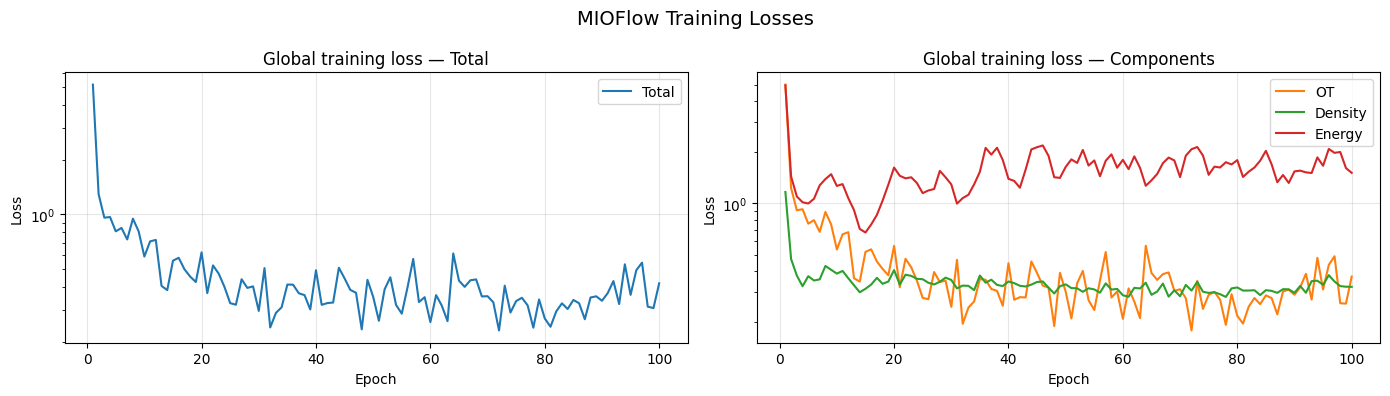

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Losses ───────────────────────────────────────────────────────────
if mf.losses and mf.losses.get('total_loss'):
    epochs = mf.losses['epoch']

    # Left: total loss
    ax = axes[0]
    ax.plot(epochs, mf.losses['total_loss'], label='Total', color='tab:blue')
    ax.set_title('Global training loss — Total')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Right: individual loss components
    ax = axes[1]
    ax.plot(epochs, mf.losses['ot_loss'],      label='OT',      color='tab:orange')
    ax.plot(epochs, mf.losses['density_loss'], label='Density', color='tab:green')
    ax.plot(epochs, mf.losses['energy_loss'],  label='Energy',  color='tab:red')
    ax.set_title('Global training loss — Components')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    axes[0].set_visible(False)
    axes[1].set_visible(False)

plt.suptitle('MIOFlow Training Losses', fontsize=14)
plt.tight_layout()
plt.show()

# To predict

<font size=1.4>

```python
def _prepare_data(self) -> 'TimeSeriesDataset':
    """Encode, normalize, and package data as a TimeSeriesDataset."""
    embedding, time_labels = self._encode()
    self.embedding = embedding # saving the latent space where we ran our model
    self._time_labels = time_labels  # saving the time_labels
    normed = self._normalize(embedding)
    groups = sorted(set(time_labels))
    time_series_data = [
        (normed[time_labels == g].astype(np.float32), float(g))
        for g in groups
    ]
    return TimeSeriesDataset(time_series_data)

def _encode(self) -> Tuple[np.ndarray, np.ndarray]:
    """Return (embedding, time_labels) as numpy arrays.

    Priority order:
    1. ``gaga_model`` — encodes ``adata.obsm[gaga_input_key]`` to latent space.
    2. Fallback — reads the raw array from ``adata.obsm[gaga_input_key]``.

    Time labels always come from ``adata.obs[obs_time_key]``.
    """

    if self.gaga_input_key not in self.adata.obsm:
        raise ValueError(f"Key '{self.gaga_input_key}' not found in adata.obsm")

    X_raw = self.adata.obsm[self.gaga_input_key].astype(np.float32)

    # If no autoencoder was used reads adata.obsm[gaga_input_key]: 
    if self.gaga_autoencoder is not None:
        scaler = getattr(self.gaga_autoencoder, 'input_scaler', None)
        X_scaled = scaler.transform(X_raw) if scaler is not None else X_raw
        self.gaga_autoencoder.eval()
        with torch.no_grad():
            embedding = self.gaga_autoencoder.encode(
                torch.tensor(X_scaled)
            ).cpu().numpy().astype(np.float64)
    else:
        embedding = X_raw.astype(np.float64)

    time_labels, _ = pd.factorize(self.adata.obs[self.obs_time_key],sort=True)
    return embedding, time_labels


```
</font>

# resume

In [ ]:
from mioflow.core.models.ode_model import ODEFunc
from mioflow.core.models.sde_model import SDEFunc

ckpt = torch.load('logs/MIOFlow/mioflow_pca_gaga_checkpoint.pt', weights_only=False)

# Rebuild GAGA
gaga_model = Autoencoder(ckpt['gaga_input_dim'], ckpt['gaga_latent_dim'], hidden_dims=ckpt['gaga_hidden_dims'])
gaga_model.load_state_dict(ckpt['gaga_state_dict'])
gaga_model.input_scaler = ckpt['scaler_pca']

# Rebuild MIOFlow (just for structure — skip fit())
mf2 = MIOFlow(adata, gaga_model=gaga_model, gaga_input_key='X_pca',
             obs_time_key='Time_point', hidden_dim=ckpt['hidden_dim'])
mf2.dataset = mf2._prepare_data()  # sets mean_vals/std_vals from data

# Override with saved normalization + load ODE weights
mf2.mean_vals = ckpt['mean_vals']
mf2.std_vals = ckpt['std_vals']

input_dim_ode = ckpt['input_dim'] - 1
mf2.ode_model = ODEFunc(input_dim=input_dim_ode, hidden_dim=ckpt['hidden_dim'])
mf2.ode_model.load_state_dict(ckpt['ode_state_dict'])
mf2.is_fitted = True


2026-03-13 23:16:55,001 - MIOFlow - INFO - MIOFlow initialised | 126861 cells, 5000 genes | device=cuda


# train KNN 

In [79]:
import sklearn.metrics
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
k = 15
x_ref = np.array(train_ad.obsm["X_pca"]).astype(np.float32)
y_ref = train_ad.obs["Annotation"].values.astype(str)

knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
knn.fit(x_ref, y_ref)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [56]:
from mioflow.core.datasets import TimeSeriesDataset

In [59]:
from torchdiffeq import odeint

In [92]:
from torch import device


def simulate(mf, start_cellbarcodes, start_time, end_time, device='cuda:0'):

    fate_ad = adata[start_cellbarcodes].copy()
    fate_X_pc_scaled = mf.gaga_autoencoder.input_scaler.transform(fate_ad.obsm['X_pca'])

    t_bins = torch.linspace(start_time, end_time, 100, device=device)

    with torch.no_grad():
        embedding = mf.gaga_autoencoder.encode(
            torch.tensor(fate_X_pc_scaled)
        ).cpu().numpy().astype(np.float64)

    normed_embedding = mf._normalize(embedding)

    with torch.no_grad():
        fate_X_ts = torch.tensor(normed_embedding).float().to(device)
        traj = odeint(mf.ode_model.to(device), fate_X_ts, t_bins)

        decoded_pc = mf.gaga_autoencoder.decode(traj[-1].cpu())

    decoded_pc = decoded_pc.detach().cpu().numpy()
    endpoint = mf.gaga_autoencoder.input_scaler.inverse_transform(decoded_pc)

    return endpoint


def train_knn(input_key="X_pca", label_key='Annotation'):

    k = 15
    x_ref = np.array(train_ad.obsm[input_key]).astype(np.float32)
    y_ref = train_ad.obs[label_key].values.astype(str)

    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(x_ref, y_ref)

    return knn

In [ ]:
F_obs = pd.read_csv("data/klein/F_obs.csv", index_col=0)
F_obs.index = F_obs.index.astype(str)
F_obs = F_obs[F_obs.index.isin(adata.obs_names.astype(str))]

In [ ]:
endpoint = simulate(mf, 
                    F_obs.index,
                    start_time=0,
                    end_time = 2,
                    device='cuda:0')

knn = train_knn()

In [93]:
y_pred = knn.predict(endpoint)
y_true = F_obs.idxmax(axis=1).tolist()
accuracy = sklearn.metrics.accuracy_score(y_true, y_pred)
print(accuracy)

0.3466272772033481


# w2

In [100]:
clone_proportions = pd.read_csv("data/klein/clone_proportions.csv", index_col=0)
w2_clone_mask = test_ad.obs.clones.isin(clone_proportions.index)
w2_test_ad = test_ad[w2_clone_mask]

src_ad_w2 = w2_test_ad[w2_test_ad.obs["Time_point"] == "4.0"]
tgt_ad_w2 = w2_test_ad[w2_test_ad.obs["Time_point"] == "6.0"]

In [102]:
w2_true = tgt_ad_w2.obsm['X_pca']

w2_endpoint = simulate(mf, 
                    src_ad_w2.obs_names,
                    start_time=1,
                    end_time = 2,
                    device='cuda:0')

w2 = fate_eval.compute_w2(w2_endpoint,w2_true)
print(w2)

14.042269432239438


In [ ]:
# prepare a time series dataset
# then we can use the ode to generate trajectories